# ddpgresnet

This notebook documents an unsupervised/reinforcement learning experiment, including environment setup and model training.

This file keeps the original experimentation style and adds a small structure note for easier navigation.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision import datasets
#import resnet50
from torchvision.models import resnet18,resnet50,resnet101
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import skimage
import random
import kagglehub

In [2]:
kagglehub.dataset_download('tallo2060/imagenmonkee', path='fae6202d-2a8b-40e3-8d05-19f46ba7b537.ce308afc0ee1b59229142849913da8f1.jpeg')

'/kaggle/input/imagenmonkee/fae6202d-2a8b-40e3-8d05-19f46ba7b537.ce308afc0ee1b59229142849913da8f1.jpeg'

In [3]:
kagglehub.dataset_download('tallo2060/monkeee')

'/kaggle/input/monkeee'

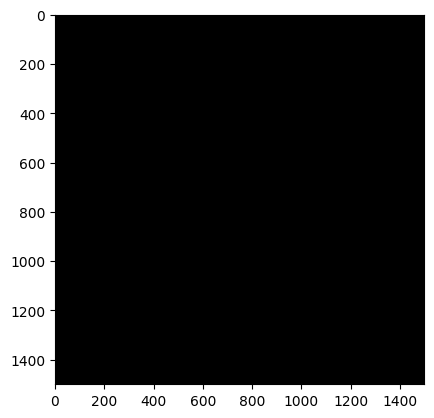

In [4]:
#create images
monkee=skimage.io.imread("../input/monkeee/fae6202d-2a8b-40e3-8d05-19f46ba7b537.ce308afc0ee1b59229142849913da8f1.jpeg")
monkee=skimage.transform.resize(monkee,(250,250))
img=monkee
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
#create 1500x1500 canvas
canvas=np.zeros((1500,1500,3))
x=750-monkee.shape[0]/2
resnetimages=[]
ys=[]
for i in range(3):
    y=random.randint(0,1000)
    canvas[int(y):int(y)+monkee.shape[0],int(x):int(x)+monkee.shape[1]]=monkee
    yinfivesec=y+(1/2)*9.8*5**2
    ys.append(yinfivesec)
    resnetimages.append(preprocess(canvas))
    canvas=np.zeros((1500,1500,3))




plt.imshow(canvas)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.set_default_device(device)
torch.set_default_tensor_type("torch.cuda.FloatTensor")

Using device: cuda


/opt/conda/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /usr/local/src/pytorch/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


In [6]:

class game():
  def __init__(self):
    self.x=450

  def reset(self):
    self.x=450
    self.y=0
    self.canvas = np.zeros((1500, 1500,3))
    self.canvas[self.y:self.y+250,self.x:self.x+250]=img
    print(self.canvas.shape)
    #resize image
    self.canvas=preprocess(self.canvas)
    return self.canvas,0,False,{}
  def step(self,action):
    self.canvas=np.zeros((1500,1500,3))
    print(self.y)
    freefall=self.y+(1/2)*9.8*(2)**2
    print("yfuture")
    print(freefall)

    self.y=freefall
    if self.y>1500-250:
      done=True
      return preprocess(self.canvas),1,done,{}
    else:
      done=False
    self.y=int(freefall)
    print()
    self.canvas[self.y:self.y+250,self.x:self.x+250]=img
    #resize image
    stateaf=preprocess(self.canvas)
    reward=self.reward(action)
    info={}
    return stateaf,reward,done,info


  def reward(self,action):
    print((self.y,action))
    return 100/(1+torch.nn.functional.mse_loss(torch.tensor(action),torch.tensor(self.y)))

In [7]:
class ResBlock(torch.nn.Module):
  def __init__(self,inn,outt,downsample):
    super(ResBlock,self).__init__()
    self.conv1=torch.nn.Conv2d(inn,outt,3,padding=1)
    self.batchnorm1=torch.nn.BatchNorm2d(outt)
    self.relu=torch.nn.ReLU()

    self.downsample = downsample
    self.avgpool=torch.nn.AvgPool2d(4,4)
    if self.downsample or inn != outt:
            self.identity_downsample = nn.Conv2d(inn, outt, kernel_size=1, stride=1)
            self.identity_batchnorm = nn.BatchNorm2d(outt)
    else:
            self.identity_downsample = None
  def forward(self,x):
    residual=self.conv1(x)
    residual=self.batchnorm1(residual)
    residual=self.relu(residual)
    identity = x
    #print("identity shape")
    #print(identity.shape)
    #print("residual shape")
    #print(residual.shape)
    if self.identity_downsample is not None:
        identity = self.identity_downsample(identity)
        #print("identity shape2")
        #print(identity.shape)
        identity = self.identity_batchnorm(identity)

        # Add residual and identity
        output = residual + identity
        output = self.relu(output)
        output = self.avgpool(output)
        return output
    else:
        output = residual + identity
        output = self.relu(output)
        output = self.avgpool(output)
        return output

    return output




In [8]:
class Qfunction(torch.nn.Module):
  def __init__(self):
    super(Qfunction,self).__init__()
    #process the image
    self.resblock1=ResBlock(3,64,True)
    self.resblock2=ResBlock(64,128,True)
    self.resblock3=ResBlock(128,256,True)
    self.flatten=torch.nn.Flatten()
    self.fullyconnected=torch.nn.Linear(2304,100)
    self.selu1=torch.nn.SELU()
    self.selu2=torch.nn.SELU()
    self.selu3=torch.nn.SELU()
    self.fulconected2=torch.nn.Linear(101,50)
    self.fulconected3=torch.nn.Linear(50,1)
    

  def forward(self,x,a):
    x=self.resblock1(x)
    x=self.resblock2(x)
    x=self.resblock3(x)
    x=self.flatten(x)
    x=self.fullyconnected(x)
    x=torch.nn.LeakyReLU()(x)
    a=torch.nn.LeakyReLU()(a)
    #concat
    x=torch.cat((x,a),dim=1)
    x=self.fulconected2(x)
    x=torch.nn.LeakyReLU()(x)
    x=self.fulconected3(x)
    
    return x
class actor(torch.nn.Module):
  def __init__(self):
    super(actor,self).__init__()
    self.resblock1=ResBlock(3,64,True)
    self.resblock2=ResBlock(64,128,True)
    self.resblock3=ResBlock(128,256,True)
    self.flatten=torch.nn.Flatten()
    self.fullyconnected=torch.nn.Linear(2304,100)
    self.selu=torch.nn.SELU()
    self.linear=torch.nn.Linear(100,1)
    self.sigmoid=torch.nn.Sigmoid()
  def forward(self,x):
    x=self.resblock1(x)
    x=self.resblock2(x)
    x=self.resblock3(x)
    x=self.flatten(x)
    x=self.fullyconnected(x)
    x=self.selu(x)
    x=self.linear(x)
    x=self.sigmoid(x)
    return x

In [9]:
from collections import deque
import json
import random

In [10]:
class trainer():
  def __init__(self,qfunction,actor,initial_eps,decay,gamma,env):
    self.qfunction=qfunction()
    self.actorpast=actor()
    self.actor=actor()
    self.qfunction=qfunction()
    self.qfunctionpast=qfunction()
    self.qfunctionpast.load_state_dict(self.qfunction.state_dict())
    self.actorpast.load_state_dict(self.actor.state_dict())
    self.gamma=gamma
    self.eps=initial_eps
    self.decay=decay
    self.buffer=deque(maxlen=10000)
    self.env=env
    self.optimizerq=torch.optim.Adam(self.qfunction.parameters(),lr=0.00005)
    self.optimizera=torch.optim.Adam(self.actor.parameters(),lr=0.00005)
    self.accre=[]
    self.norm=torch.distributions.Normal(0,1)

  def collecttrayectories(self,t):
    while t>0:
      state,reward,done,info=self.env.reset()
      acumulated=0

      while not done:
        state=state.unsqueeze(0)  
        action=self.actor(state.cuda()) if random.random() > self.eps else torch.rand((1,1))
        action=torch.clamp(action,0,1)
        action=action*1500
        action=action.detach()
        next_state,reward,done,info=self.env.step(action)
        next_state=next_state.cuda()
        self.buffer.append((state.detach(),action.detach(),reward,next_state.detach(),done))
        state=next_state
        t=t-1
        acumulated=acumulated+reward
        
      self.accre.append(acumulated.cpu())
      plt.plot(self.accre)
      plt.savefig("accreward")
      plt.clf()
      clear_output()

  def gradientstep(self,epochs):
    #batch=random.sample(self.buffer,30)
    #states,actions,rewards,next_states,dones=zip(*batch)
    for i in range(epochs):
      batch=random.sample(self.buffer,30)
      states,actions,rewards,next_states,dones=zip(*batch)
      
      
      concatlossesq=torch.tensor([[0]]).float()
      concatlossesa=torch.tensor([[0]]).float()
      self.eps*=self.decay
      for z in range(len(states)):
        actual_state=states[z].cuda()
        actual_action=actions[z]
        actual_reward=rewards[z]
        actual_next_state=next_states[z].cuda()
        actual_done=dones[z]
        #actual_state=actual_state.unsqueeze(0)
        actual_next_state=actual_next_state.unsqueeze(0)
        #print("actual state")
        #print(actual_state.shape)
        #print("actual next state")
        #print(actual_next_state.shape)
        actorpast=self.actorpast(actual_next_state)
        q_past=self.qfunctionpast(actual_next_state,actorpast)
        y=actual_reward+self.gamma*(1-int(actual_done))*q_past
        y=torch.reshape(y,(-1,1))
        actualq=self.qfunction(actual_state,actual_action)
        lossq=torch.nn.SmoothL1Loss()(actualq,y)
        #lossq=actualq
        concatlossesq=concatlossesq + lossq
        actual_actor=self.actor(actual_state)
        xd=torch.Tensor([[1500]]).detach()
        

        lossa=-self.qfunction(actual_state.detach(),actual_actor)
        concatlossesa=concatlossesa + lossa
      concatlossesq=concatlossesq/len(states)
      concatlossesa=concatlossesa/len(states)
      #self.optimizerq.zero_grad()

      #concatlossesq.backward(retain_graph=True)
      
      #self.optimizerq.step()
      self.optimizera.zero_grad()
      self.optimizerq.zero_grad()
      concatlossesa.backward(retain_graph=True)
      torch.nn.utils.clip_grad_norm_(self.actor.parameters(),max_norm=1)
      concatlossesq.backward(retain_graph=True)
      torch.nn.utils.clip_grad_norm_(self.qfunction.parameters(),max_norm=1)
      self.optimizera.step()
      self.optimizerq.step()
      
      self.printgrad(concatlossesq,concatlossesa)
  def update(self,p):
    with torch.no_grad():
      for param,target_param in zip(self.qfunction.parameters(),self.qfunctionpast.parameters()):
        target_param.data.copy_(p*target_param.data+(1-p)*param.data)
      for param2,target_param2 in zip(self.actor.parameters(),self.actorpast.parameters()):
        target_param2.data.copy_(p*target_param2.data+(1-p)*param2.data)
  def printgrad(self,lossq,lossa):
    prms={}
    for name,param in self.qfunction.named_parameters():
      if param.requires_grad:
        #print(name)
        #print(param.grad)
        prms[name]=str(param.grad.cpu().detach().numpy())
    for name,param in self.actor.named_parameters():
        if param.requires_grad:
            prms[name+"actor"]=str(param.grad.cpu().detach().numpy())
    prms["eps"]=self.eps
    prms["qlo"]=str(lossq)
    prms["lossa"]=str(lossa)
    
    with open('data.json', 'w') as json_file:
      json.dump(prms, json_file)






In [11]:
from IPython.display import clear_output

In [ ]:
#main loop
train=trainer(Qfunction,actor,0.999,0.999,0.99,game())
idk=500
torch.autograd.set_detect_anomaly(True)
for i in range(idk):
  train.collecttrayectories(30)
  train.gradientstep(10)
  
  if i%10==0:
    train.update(0.7)
    
    
  clear_output()
